In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



Plot saved to: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output/Model_Comparison_AUROC.png


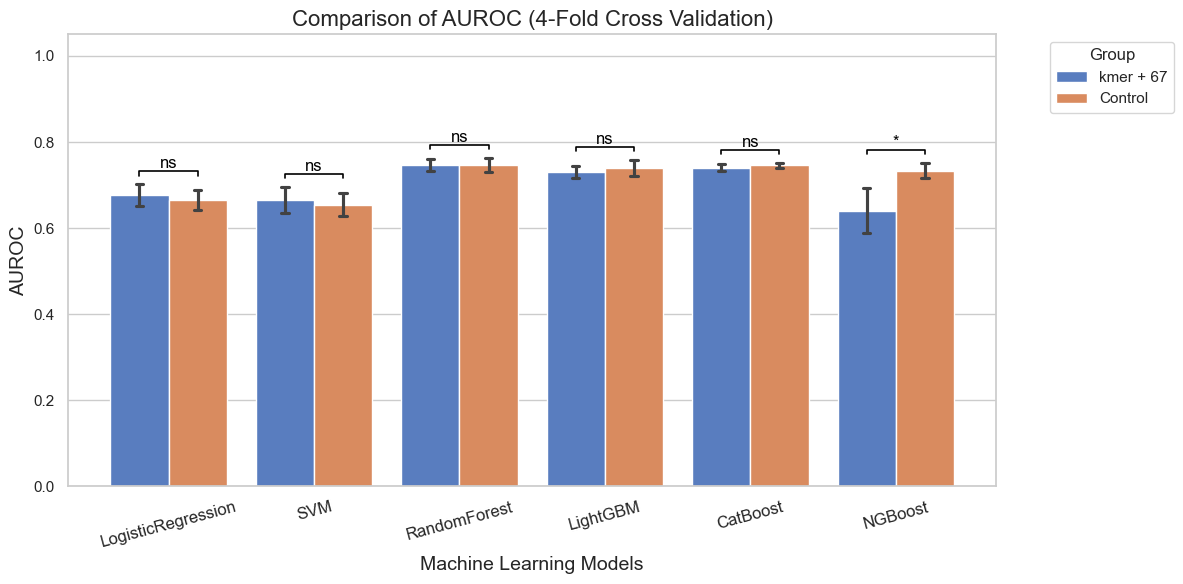

In [2]:
# 定义路径
base_dir_kmer67 = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output"
base_dir_control = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output"

models = [
    "LogisticRegression", 
    "SVM", 
    "RandomForest", 
    "LightGBM", 
    "CatBoost_RandomSearch", 
    "NGBoost_RandomSearch"
]

# 我们选取主要评估指标
metric_to_plot = "AUROC" # 你也可以改为 "AUPRC", "Accuracy", "F1_Score" 等

data_list = []

# 读取数据
for model in models:
    # 实验组
    path_ablation = os.path.join(base_dir_kmer67, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_ablation):
        df_abl = pd.read_csv(path_ablation)
        for val in df_abl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "kmer + 67", metric_to_plot: val})
            
    # 对照组
    path_control = os.path.join(base_dir_control, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_control):
        df_ctrl = pd.read_csv(path_control)
        for val in df_ctrl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "Control", metric_to_plot: val})

# 转换为 DataFrame
df_all = pd.DataFrame(data_list)

# 确保模型标签简化，为了美观
df_all['Model'] = df_all['Model'].str.replace("_RandomSearch", "")

import scipy.stats as stats

# 获取显著性星号的函数
def get_asterisks_for_pval(p_val):
    if p_val > 0.05:
        return 'ns'
    elif p_val <= 0.0001:
        return '****'
    elif p_val <= 0.001:
        return '***'
    elif p_val <= 0.01:
        return '**'
    elif p_val <= 0.05:
        return '*'

# 绘图
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 使用 seaborn 绘制带误差线的分组柱状图 (默认显示均值 + 95%置信区间，可改为标准差 ci="sd")
ax = sns.barplot(
    data=df_all, 
    x="Model", 
    y=metric_to_plot, 
    hue="Group", 
    palette="muted", 
    capsize=.1, 
    errorbar="sd"
)

# --- 显著性检验与标注 ---
models_clean = df_all['Model'].unique()
for i, model_name in enumerate(models_clean):
    # 获取两组数据
    data_abl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'kmer + 67')][metric_to_plot]
    data_ctrl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'Control')][metric_to_plot]
    
    if len(data_abl) > 1 and len(data_ctrl) > 1:
        # 执行独立样本 T 检验 (由于折数较少且独立，假设方差不齐)
        t_stat, p_val = stats.ttest_ind(data_abl, data_ctrl, equal_var=False)
        ast = get_asterisks_for_pval(p_val)
        
        # 获取两组柱子的中心X坐标（对于2个hue的seaborn barplot，偏移约为 -0.2 和 +0.2）
        x1, x2 = i - 0.2, i + 0.2
        
        # 获取Y轴上的最高点(均值+标准差)，以防遮挡图表
        max_y = max(data_abl.mean() + data_abl.std(), data_ctrl.mean() + data_ctrl.std())
        y = max_y + 0.02
        h = 0.01
        
        # 绘制横线与星号
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
        plt.text((x1+x2)*.5, y+h, ast, ha='center', va='bottom', color='black', fontsize=12)

plt.title(f'Comparison of {metric_to_plot} (4-Fold Cross Validation)', fontsize=16)
plt.ylabel(metric_to_plot, fontsize=14)
plt.xlabel('Machine Learning Models', fontsize=14)
plt.xticks(rotation=15, fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 保存图片
output_png = os.path.join(base_dir_kmer67, f"Model_Comparison_{metric_to_plot}.png")
plt.savefig(output_png, dpi=300)
print(f"Plot saved to: {output_png}")
plt.show()

Plot saved to: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output/Model_Comparison_AUPRC.png


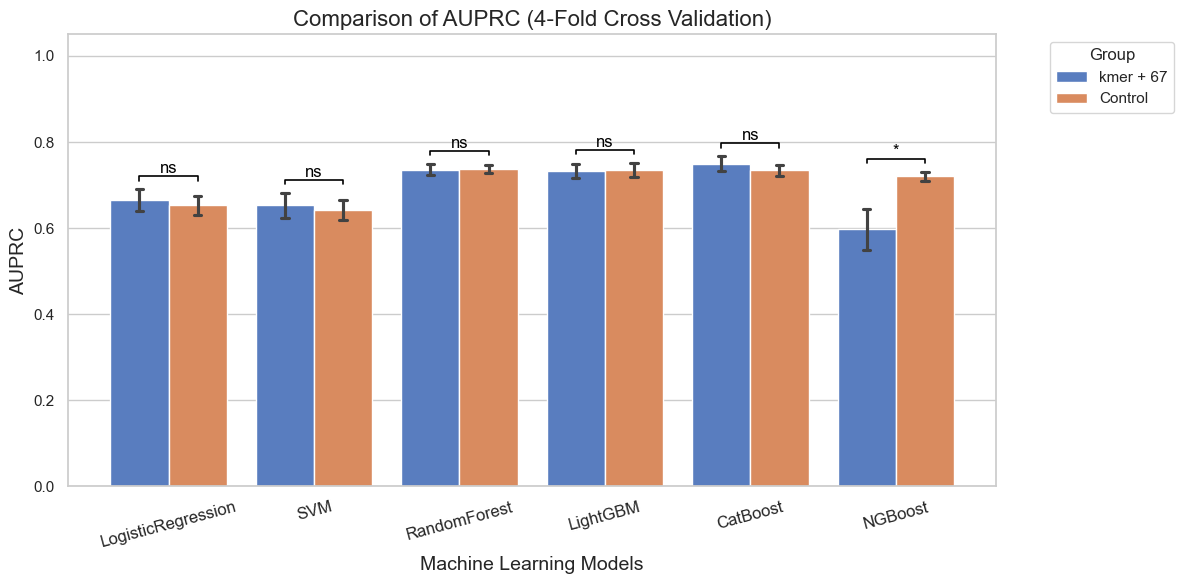

In [3]:
# 定义路径
base_dir_kmer67 = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output"
base_dir_control = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output"

models = [
    "LogisticRegression", 
    "SVM", 
    "RandomForest", 
    "LightGBM", 
    "CatBoost_RandomSearch", 
    "NGBoost_RandomSearch"
]

# 我们选取主要评估指标
metric_to_plot = "AUPRC" # 你也可以改为 "AUPRC", "Accuracy", "F1_Score" 等

data_list = []

# 读取数据
for model in models:
    # 实验组
    path_ablation = os.path.join(base_dir_kmer67, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_ablation):
        df_abl = pd.read_csv(path_ablation)
        for val in df_abl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "kmer + 67", metric_to_plot: val})
            
    # 对照组
    path_control = os.path.join(base_dir_control, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_control):
        df_ctrl = pd.read_csv(path_control)
        for val in df_ctrl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "Control", metric_to_plot: val})

# 转换为 DataFrame
df_all = pd.DataFrame(data_list)

# 确保模型标签简化，为了美观
df_all['Model'] = df_all['Model'].str.replace("_RandomSearch", "")

import scipy.stats as stats

# 获取显著性星号的函数
def get_asterisks_for_pval(p_val):
    if p_val > 0.05:
        return 'ns'
    elif p_val <= 0.0001:
        return '****'
    elif p_val <= 0.001:
        return '***'
    elif p_val <= 0.01:
        return '**'
    elif p_val <= 0.05:
        return '*'

# 绘图
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 使用 seaborn 绘制带误差线的分组柱状图 (默认显示均值 + 95%置信区间，可改为标准差 ci="sd")
ax = sns.barplot(
    data=df_all, 
    x="Model", 
    y=metric_to_plot, 
    hue="Group", 
    palette="muted", 
    capsize=.1, 
    errorbar="sd"
)

# --- 显著性检验与标注 ---
models_clean = df_all['Model'].unique()
for i, model_name in enumerate(models_clean):
    # 获取两组数据
    data_abl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'kmer + 67')][metric_to_plot]
    data_ctrl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'Control')][metric_to_plot]
    
    if len(data_abl) > 1 and len(data_ctrl) > 1:
        # 执行独立样本 T 检验 (由于折数较少且独立，假设方差不齐)
        t_stat, p_val = stats.ttest_ind(data_abl, data_ctrl, equal_var=False)
        ast = get_asterisks_for_pval(p_val)
        
        # 获取两组柱子的中心X坐标（对于2个hue的seaborn barplot，偏移约为 -0.2 和 +0.2）
        x1, x2 = i - 0.2, i + 0.2
        
        # 获取Y轴上的最高点(均值+标准差)，以防遮挡图表
        max_y = max(data_abl.mean() + data_abl.std(), data_ctrl.mean() + data_ctrl.std())
        y = max_y + 0.02
        h = 0.01
        
        # 绘制横线与星号
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
        plt.text((x1+x2)*.5, y+h, ast, ha='center', va='bottom', color='black', fontsize=12)

plt.title(f'Comparison of {metric_to_plot} (4-Fold Cross Validation)', fontsize=16)
plt.ylabel(metric_to_plot, fontsize=14)
plt.xlabel('Machine Learning Models', fontsize=14)
plt.xticks(rotation=15, fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 保存图片
output_png = os.path.join(base_dir_kmer67, f"Model_Comparison_{metric_to_plot}.png")
plt.savefig(output_png, dpi=300)
print(f"Plot saved to: {output_png}")
plt.show()

Plot saved to: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output/Model_Comparison_Accuracy.png


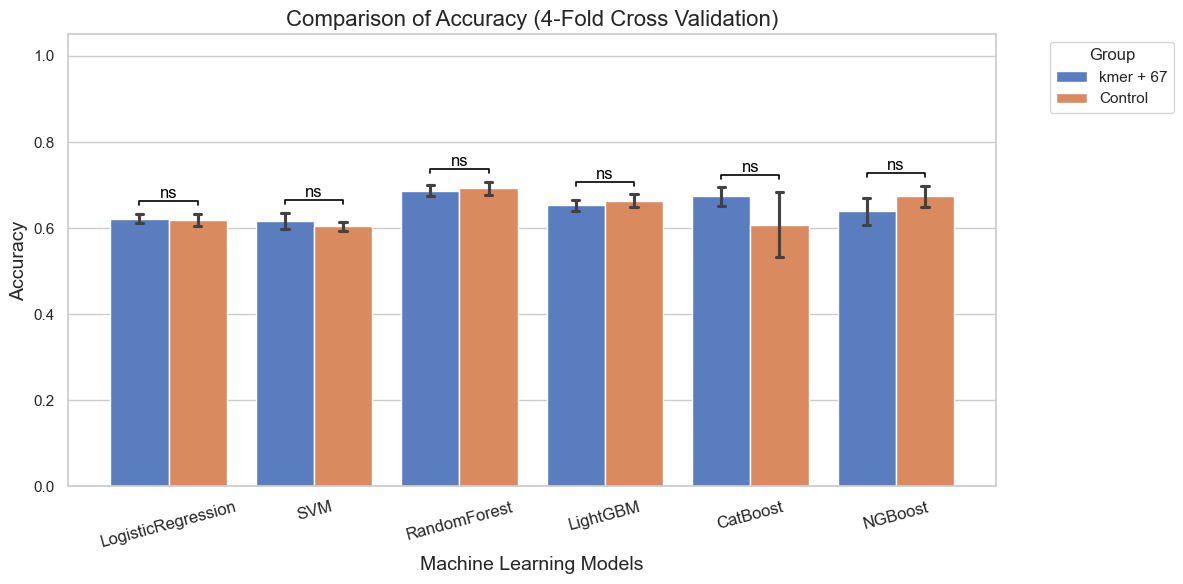

In [4]:
# 定义路径
base_dir_kmer67 = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output"
base_dir_control = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output"

models = [
    "LogisticRegression", 
    "SVM", 
    "RandomForest", 
    "LightGBM", 
    "CatBoost_RandomSearch", 
    "NGBoost_RandomSearch"
]

# 我们选取主要评估指标
metric_to_plot = "Accuracy" # 你也可以改为 "AUPRC", "Accuracy", "F1_Score" 等

data_list = []

# 读取数据
for model in models:
    # 实验组
    path_ablation = os.path.join(base_dir_kmer67, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_ablation):
        df_abl = pd.read_csv(path_ablation)
        for val in df_abl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "kmer + 67", metric_to_plot: val})
            
    # 对照组
    path_control = os.path.join(base_dir_control, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_control):
        df_ctrl = pd.read_csv(path_control)
        for val in df_ctrl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "Control", metric_to_plot: val})

# 转换为 DataFrame
df_all = pd.DataFrame(data_list)

# 确保模型标签简化，为了美观
df_all['Model'] = df_all['Model'].str.replace("_RandomSearch", "")

import scipy.stats as stats

# 获取显著性星号的函数
def get_asterisks_for_pval(p_val):
    if p_val > 0.05:
        return 'ns'
    elif p_val <= 0.0001:
        return '****'
    elif p_val <= 0.001:
        return '***'
    elif p_val <= 0.01:
        return '**'
    elif p_val <= 0.05:
        return '*'

# 绘图
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 使用 seaborn 绘制带误差线的分组柱状图 (默认显示均值 + 95%置信区间，可改为标准差 ci="sd")
ax = sns.barplot(
    data=df_all, 
    x="Model", 
    y=metric_to_plot, 
    hue="Group", 
    palette="muted", 
    capsize=.1, 
    errorbar="sd"
)

# --- 显著性检验与标注 ---
models_clean = df_all['Model'].unique()
for i, model_name in enumerate(models_clean):
    # 获取两组数据
    data_abl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'kmer + 67')][metric_to_plot]
    data_ctrl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'Control')][metric_to_plot]
    
    if len(data_abl) > 1 and len(data_ctrl) > 1:
        # 执行独立样本 T 检验 (由于折数较少且独立，假设方差不齐)
        t_stat, p_val = stats.ttest_ind(data_abl, data_ctrl, equal_var=False)
        ast = get_asterisks_for_pval(p_val)
        
        # 获取两组柱子的中心X坐标（对于2个hue的seaborn barplot，偏移约为 -0.2 和 +0.2）
        x1, x2 = i - 0.2, i + 0.2
        
        # 获取Y轴上的最高点(均值+标准差)，以防遮挡图表
        max_y = max(data_abl.mean() + data_abl.std(), data_ctrl.mean() + data_ctrl.std())
        y = max_y + 0.02
        h = 0.01
        
        # 绘制横线与星号
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
        plt.text((x1+x2)*.5, y+h, ast, ha='center', va='bottom', color='black', fontsize=12)

plt.title(f'Comparison of {metric_to_plot} (4-Fold Cross Validation)', fontsize=16)
plt.ylabel(metric_to_plot, fontsize=14)
plt.xlabel('Machine Learning Models', fontsize=14)
plt.xticks(rotation=15, fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 保存图片
output_png = os.path.join(base_dir_kmer67, f"Model_Comparison_{metric_to_plot}.png")
plt.savefig(output_png, dpi=300)
print(f"Plot saved to: {output_png}")
plt.show()

Plot saved to: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output/Model_Comparison_F1_Score.png


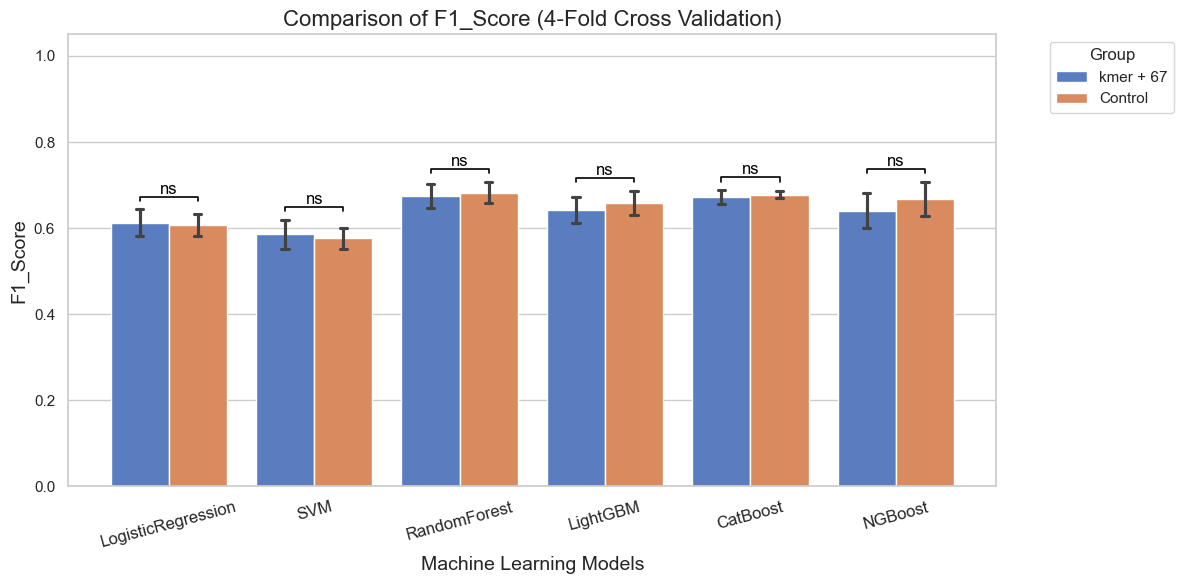

In [5]:
# 定义路径
base_dir_kmer67 = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output"
base_dir_control = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output"

models = [
    "LogisticRegression", 
    "SVM", 
    "RandomForest", 
    "LightGBM", 
    "CatBoost_RandomSearch", 
    "NGBoost_RandomSearch"
]

# 我们选取主要评估指标
metric_to_plot = "F1_Score" # 你也可以改为 "AUPRC", "Accuracy", "F1_Score" 等

data_list = []

# 读取数据
for model in models:
    # 实验组
    path_ablation = os.path.join(base_dir_kmer67, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_ablation):
        df_abl = pd.read_csv(path_ablation)
        for val in df_abl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "kmer + 67", metric_to_plot: val})
            
    # 对照组
    path_control = os.path.join(base_dir_control, model, "All_Folds_Evaluate_Results.csv")
    if os.path.exists(path_control):
        df_ctrl = pd.read_csv(path_control)
        for val in df_ctrl[metric_to_plot]:
            data_list.append({"Model": model, "Group": "Control", metric_to_plot: val})

# 转换为 DataFrame
df_all = pd.DataFrame(data_list)

# 确保模型标签简化，为了美观
df_all['Model'] = df_all['Model'].str.replace("_RandomSearch", "")

import scipy.stats as stats

# 获取显著性星号的函数
def get_asterisks_for_pval(p_val):
    if p_val > 0.05:
        return 'ns'
    elif p_val <= 0.0001:
        return '****'
    elif p_val <= 0.001:
        return '***'
    elif p_val <= 0.01:
        return '**'
    elif p_val <= 0.05:
        return '*'

# 绘图
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 使用 seaborn 绘制带误差线的分组柱状图 (默认显示均值 + 95%置信区间，可改为标准差 ci="sd")
ax = sns.barplot(
    data=df_all, 
    x="Model", 
    y=metric_to_plot, 
    hue="Group", 
    palette="muted", 
    capsize=.1, 
    errorbar="sd"
)

# --- 显著性检验与标注 ---
models_clean = df_all['Model'].unique()
for i, model_name in enumerate(models_clean):
    # 获取两组数据
    data_abl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'kmer + 67')][metric_to_plot]
    data_ctrl = df_all[(df_all['Model'] == model_name) & (df_all['Group'] == 'Control')][metric_to_plot]
    
    if len(data_abl) > 1 and len(data_ctrl) > 1:
        # 执行独立样本 T 检验 (由于折数较少且独立，假设方差不齐)
        t_stat, p_val = stats.ttest_ind(data_abl, data_ctrl, equal_var=False)
        ast = get_asterisks_for_pval(p_val)
        
        # 获取两组柱子的中心X坐标（对于2个hue的seaborn barplot，偏移约为 -0.2 和 +0.2）
        x1, x2 = i - 0.2, i + 0.2
        
        # 获取Y轴上的最高点(均值+标准差)，以防遮挡图表
        max_y = max(data_abl.mean() + data_abl.std(), data_ctrl.mean() + data_ctrl.std())
        y = max_y + 0.02
        h = 0.01
        
        # 绘制横线与星号
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
        plt.text((x1+x2)*.5, y+h, ast, ha='center', va='bottom', color='black', fontsize=12)

plt.title(f'Comparison of {metric_to_plot} (4-Fold Cross Validation)', fontsize=16)
plt.ylabel(metric_to_plot, fontsize=14)
plt.xlabel('Machine Learning Models', fontsize=14)
plt.xticks(rotation=15, fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 保存图片
output_png = os.path.join(base_dir_kmer67, f"Model_Comparison_{metric_to_plot}.png")
plt.savefig(output_png, dpi=300)
print(f"Plot saved to: {output_png}")
plt.show()

Plot saved to: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/kmer_num_analysis/kmer67_extra4fold_output/RandomForest_Metrics_Boxplot.png


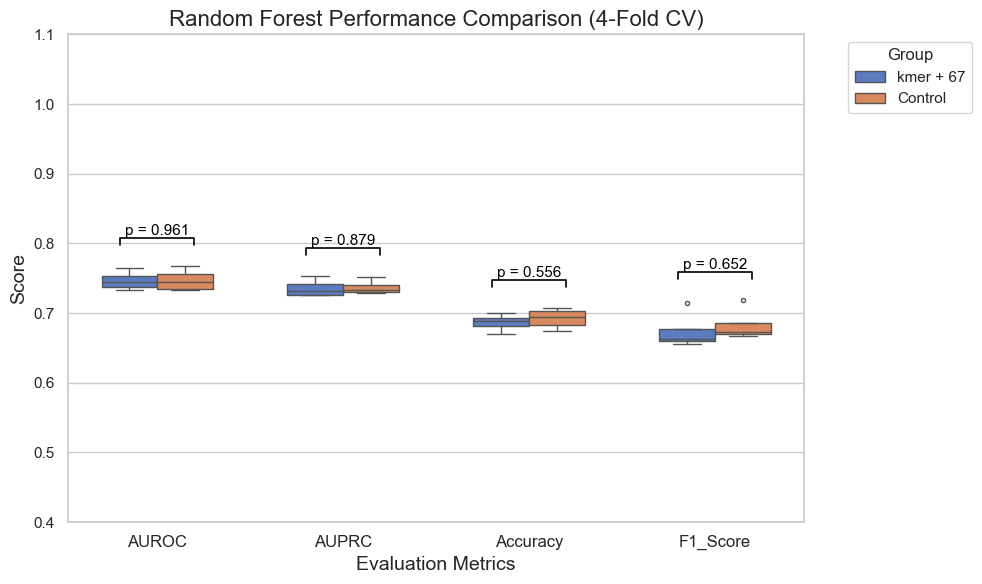

In [6]:
# 只选择 RandomForest
target_model = "RandomForest"
metrics_to_plot = ["AUROC", "AUPRC", "Accuracy", "F1_Score"]

data_list = []

# --- 1. 读取数据 ---
# 实验组
path_ablation = os.path.join(base_dir_kmer67, target_model, "All_Folds_Evaluate_Results.csv")
if os.path.exists(path_ablation):
    df_abl = pd.read_csv(path_ablation)
    for metric in metrics_to_plot:
        for val in df_abl[metric]:
            data_list.append({"Group": "kmer + 67", "Metric": metric, "Value": val})
            
# 对照组
path_control = os.path.join(base_dir_control, target_model, "All_Folds_Evaluate_Results.csv")
if os.path.exists(path_control):
    df_ctrl = pd.read_csv(path_control)
    for metric in metrics_to_plot:
        for val in df_ctrl[metric]:
            data_list.append({"Group": "Control", "Metric": metric, "Value": val})

# 转换为 DataFrame
df_all = pd.DataFrame(data_list)

# --- 3. 绘图 ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 绘制箱线图
ax = sns.boxplot(
    data=df_all, 
    x="Metric", 
    y="Value", 
    hue="Group", 
    palette="muted",
    width=0.6,
    fliersize=3
)

# --- 4. 组间显著性检验与标注 ---
for i, metric in enumerate(metrics_to_plot):
    # 保证按原始读取顺序（Fold 1 -> 4）成对出现
    data_abl = df_all[(df_all['Metric'] == metric) & (df_all['Group'] == 'kmer + 67')]['Value'].values
    data_ctrl = df_all[(df_all['Metric'] == metric) & (df_all['Group'] == 'Control')]['Value'].values
    
    if len(data_abl) > 1 and len(data_ctrl) > 1:
        # 使用独立样本 T 检验 (Independent T-test，假设方差不齐)
        t_stat, p_val = stats.ttest_ind(data_abl, data_ctrl, equal_var=False)
    
        # 直接格式化显示 p 值
        p_text = f"p = {p_val:.3f}"
        
        # 获取两组箱子的中心X坐标 (对于 width=0.6 的两个 hue，大概偏移 0.2)
        x1, x2 = i - 0.2, i + 0.2
        
        # 寻找这一指标中的最大值，以决定标注线的高度
        max_val = max(data_abl.max(), data_ctrl.max())
        y = max_val + 0.03
        h = 0.01
        
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
        plt.text((x1+x2)*.5, y+h, p_text, ha='center', va='bottom', color='black', fontsize=11)

# 图表装饰
plt.title('Random Forest Performance Comparison (4-Fold CV)', fontsize=16)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Evaluation Metrics', fontsize=14)
plt.xticks(fontsize=12)
plt.ylim(0.4, 1.1)  # 留出顶部空间显示显著性星号，可根据实际值域上下调
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 保存并显示
output_png = os.path.join(base_dir_kmer67, "RandomForest_Metrics_Boxplot.png")
plt.savefig(output_png, dpi=300)
print(f"Plot saved to: {output_png}")
plt.show()